In [1]:
import os
import pickle
import numpy as np
import glob
import pandas as pd
import matplotlib.pyplot as plt
import mne
import torch

In [2]:
folder_path = r'\\10.20.37.22\dataset0\weiting\graph_koopman\preprocessed_HUPdata_500resample_80_200_100s\HUP060'
data_path = os.path.join(folder_path, 'run01.pkl')
soz_path = os.path.join(folder_path, 'soz_info.pkl')
resected_path = os.path.join(folder_path, 'resect_info.pkl')

with open(data_path,'rb') as file:
    data = pickle.load(file)

with open(soz_path,'rb') as f:
    soz_info = pickle.load(f)
    soz_channels = soz_info.get('soz_channel_indices', [])

with open(resected_path,'rb') as f:
    resect_info = pickle.load(f)
    resect_channels = resect_info.get('resect_channel_indices', [])

print(data.shape)
print(soz_channels)
print(resect_channels)

(36, 50001)
[28, 29, 32, 35]
[26, 27, 28, 30, 31, 32, 33, 34, 35]


In [3]:
# Normalization
normalized_data = data/np.percentile(data, 95)
print(normalized_data.shape)

(36, 50001)


[]

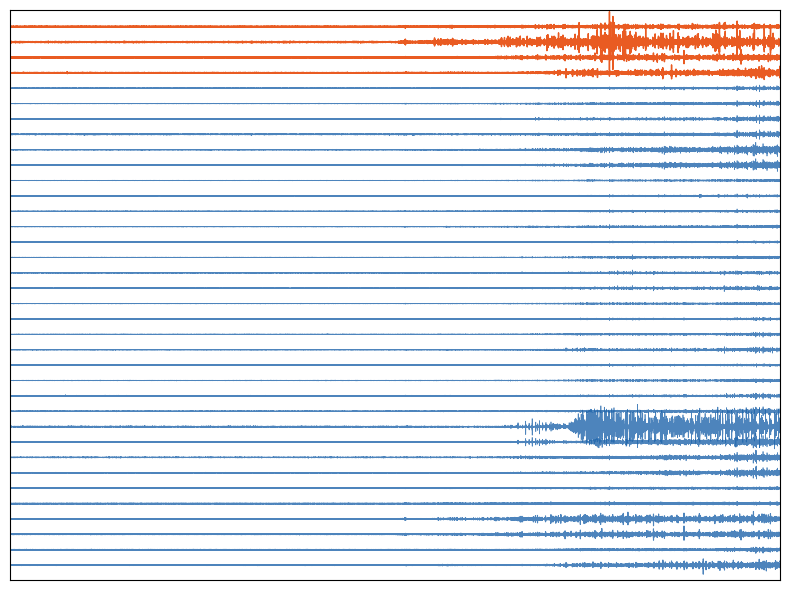

In [4]:
# Plot iEEG signals
from pathlib import Path

sampling_rate = 500

n_channels, n_samples = normalized_data.shape
duration = n_samples / sampling_rate
time_axis = np.arange(n_samples) / sampling_rate

non_soz_channels = [i for i in range(n_channels) if i not in soz_channels]
channel_order = soz_channels + non_soz_channels
reordered_data = normalized_data[channel_order,:]


fig_height = min(10, n_channels * 0.3) 
fig, ax = plt.subplots(figsize=(8, 6))
ax.invert_yaxis()

channel_spacing = np.std(normalized_data) * 35  


for plot_idx, i in enumerate(channel_order):

    signal = reordered_data[plot_idx, :] + plot_idx * channel_spacing

    if i in soz_channels:
        color = "#e95b22"          # SOZ channel marked RED
        linewidth = 1.0
        alpha = 1 #1.0
    elif i in resect_channels:
        color = '#2166ac'         # Resected channel marked BLUE
        linewidth = 0.8 #0.8
        alpha = 0.8 
    else:
        color = '#2166ac'        # Other channels marked GRAY
        linewidth = 0.5
        alpha = 0.8
    
    ax.plot(time_axis, signal, color=color, linewidth=linewidth, alpha=alpha)

start_time = 0
ax.set_xlim(start_time, duration)

legend_elements = [
    plt.Line2D([0], [0], color='red', linewidth=2, label=f'SOZ channels ({len(soz_channels)})'),
    plt.Line2D([0], [0], color='blue', linewidth=2, label=f'Resected channels ({len(resect_channels)})'),
    plt.Line2D([0], [0], color='gray', linewidth=1, label=f'Other channels ({n_channels - len(soz_channels) - len(resect_channels)})')
]


major_ticks = np.arange(start_time, duration , 5)
minor_ticks = np.arange(start_time, duration , 1)

yticklabels = []
for i in range(n_channels):
    label = f'Ch{i:03d}'
    if i in soz_channels:
        label += ' (SOZ)'
    elif i in resect_channels:
        label += ' (Resect)'
    yticklabels.append(label)


min_y = reordered_data[-1, :].min() + (n_channels - 1) * channel_spacing
max_y = reordered_data[0, :].max() + 0 * channel_spacing

margin = (max_y - min_y) * 0.04
ax.set_ylim(min_y - margin, max_y + margin)

ax.set_xticks([], minor=False) 
ax.set_xticks([], minor=True)  
ax.set_yticks([], minor=False) 
ax.set_yticks([], minor=True)

plt.tight_layout()
ax.grid(False)

ax.set_xticklabels([])
ax.set_yticklabels([])


In [5]:
# Calculate correlation coefficient
def corr_coeff(A):

    eps = 1e-10  
    A = torch.as_tensor(A, dtype=torch.float32)
    B, N, M = A.shape

    # Z-score
    m = A.mean(dim=-1, keepdim=True)  # mean
    s = A.std(dim=-1, keepdim=True,unbiased=True) # std
    Z = (A - m) / s.clamp(min=eps)
 
    corr = torch.matmul(Z, Z.transpose(-1, -2)) / (M - 1)

    return corr - torch.diag_embed(torch.diagonal(corr, dim1=-2, dim2=-1))  # without diagonal elements

In [6]:
n_channels, n_samples = data.shape
win_size = 500 # 1s
over_lap = 50 # 0.1s

sub_data = []
for start in range(0,n_samples-win_size,over_lap):

    sub_data.append(normalized_data[:,start:start+win_size])
sub_data = np.array(sub_data)
print(sub_data.shape)

ori_graph_ = corr_coeff(sub_data) # FC_graph,  window*node*node

print(ori_graph_.shape)

(991, 36, 500)
torch.Size([991, 36, 36])


In [7]:
# Vectorize the FC matrices

n_windows, n_nodes, _ = ori_graph_.shape
n_features = n_nodes * n_nodes 

# flatten the FC matrices to shape (n_windows, n_features)
X_flat = ori_graph_.reshape(n_windows, n_features)

triu_indices = np.triu_indices(n_nodes, k=1)
flat_indices = triu_indices[0] * n_nodes + triu_indices[1]

dynamics_graph = X_flat[:, flat_indices]  
print(dynamics_graph.shape)

torch.Size([991, 630])


In [28]:
# calculate koopman operator

from sklearn.utils.extmath import randomized_svd

window = 30
step = 5

dynamics_graph = np.asarray(dynamics_graph)

subj_singular_values = []
subj_right_vectors = []
subj_left_vectors = []
subj_energy = []

n_total_steps = dynamics_graph.shape[0]

for k in range(0, n_total_steps - window - 1, step): 
    
    X = dynamics_graph[k : k + window, :]
    Y = dynamics_graph[k + 1 : k + 1 + window, :]


    K = np.linalg.lstsq(X, Y, rcond=1e-10)[0]
    # print('K.shape is',K.shape)
        
    #  total energy of K 
    total_energy = np.linalg.norm(K, 'fro')**2

    #  SVD 
    U, Sigma, Vt = randomized_svd(K, n_components=10, n_iter=3, n_oversamples=10)


    subj_singular_values.append(Sigma)
    subj_right_vectors.append(Vt.T) 
    subj_left_vectors.append(U)
    subj_energy.append(total_energy)


In [9]:
# reconstruct the symmetric matrix from the vectorized upper triangular part
def symmetric_vector_to_matrix(vector, n):
   
    matrix = np.zeros((n, n))

    indices = np.tril_indices(n,-1)
    
    matrix[indices] = vector
    matrix = matrix + matrix.T 
    
    return matrix

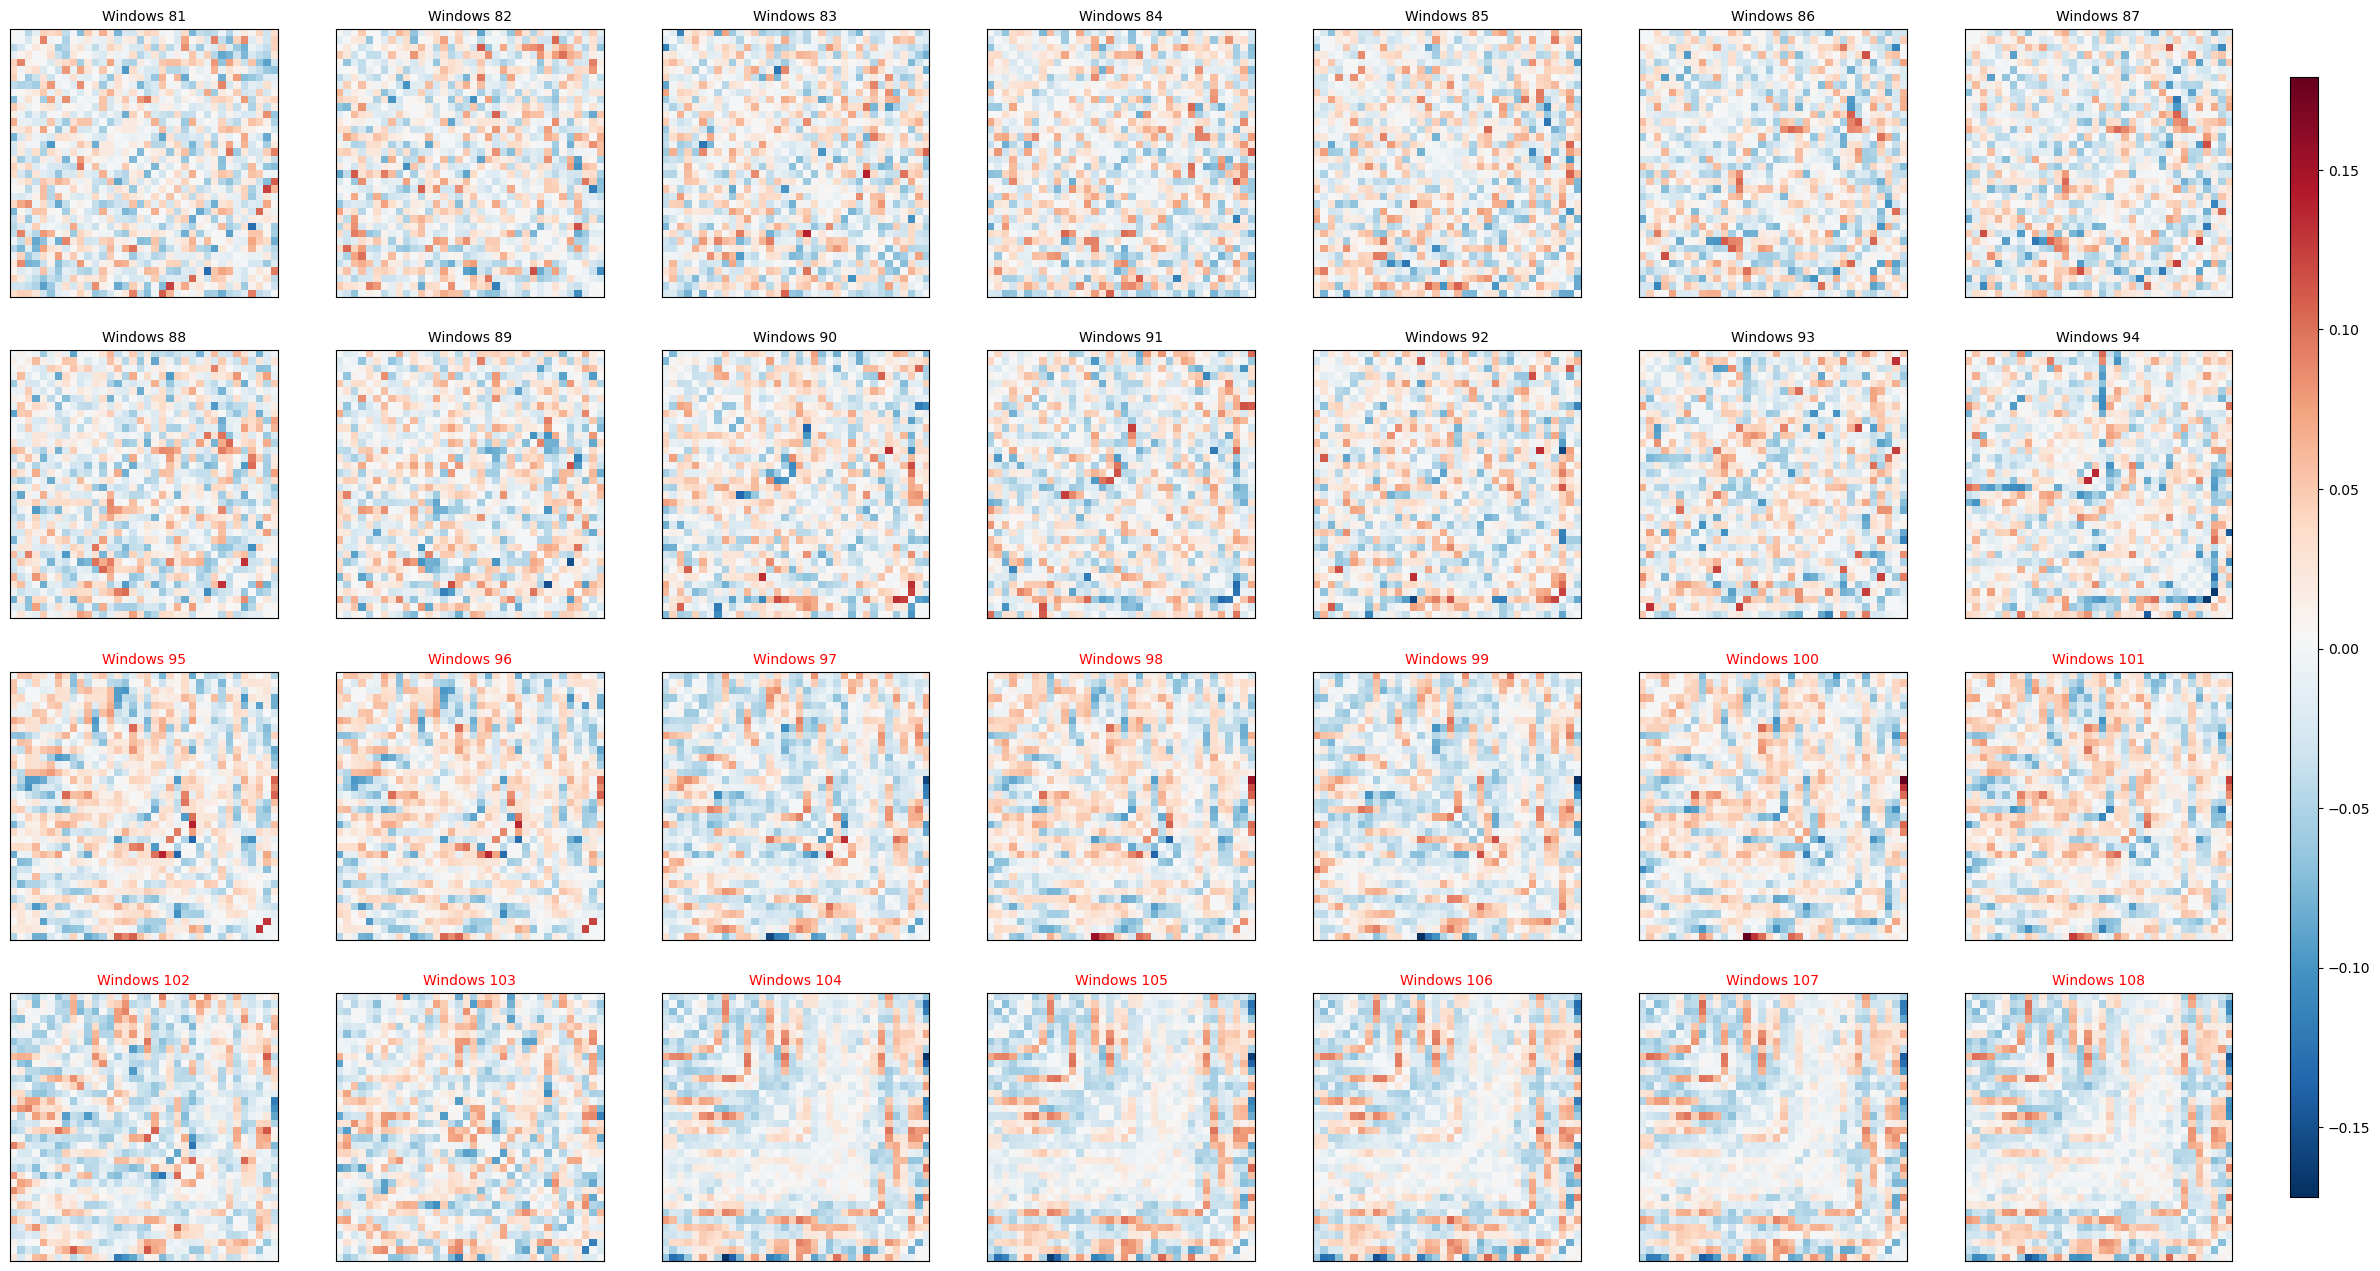

In [30]:
# Plot singular vector matrices before and after seizure

def svd_vectors_matrix_plot(data, n_nodes, mode_id):

    SEIZURE_ONSET_WINDOW = 95

    plot_data_slice = data[SEIZURE_ONSET_WINDOW-14:SEIZURE_ONSET_WINDOW+14, :,mode_id]

    vmin = plot_data_slice.min()
    vmax = plot_data_slice.max()

    fig, axes = plt.subplots(4, 7, figsize=(28, 16))
    axes = axes.flatten()  

    window_indices_to_plot = range(SEIZURE_ONSET_WINDOW-14,SEIZURE_ONSET_WINDOW+14)

    for plot_idx, win_idx in enumerate(window_indices_to_plot):
        
        ax = axes[plot_idx]
        matrix = data[win_idx,:,mode_id]

        result = symmetric_vector_to_matrix(matrix, n_nodes)

    
        im = ax.imshow(result, cmap='RdBu_r', aspect='equal', vmin=vmin, vmax=vmax) 

        title = f'Windows {win_idx}'
        color = 'black'
        if win_idx >= SEIZURE_ONSET_WINDOW:
            color = 'red'  # marked the seizure window red
        ax.set_title(title, color=color, fontsize=10)

        ax.set_xticks([])
        ax.set_yticks([])

    fig.subplots_adjust(right=0.92)  
    cbar_ax = fig.add_axes([0.94, 0.15, 0.01, 0.7])  
    fig.colorbar(im, cax=cbar_ax)
    plt.show()


svd_vectors_matrix_plot(np.array(subj_right_vectors),n_channels,0)
